## EDA and data preprocessing

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("train.csv")

In [3]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [4]:
df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
8688,9276_01,Europa,False,A/98/P,55 Cancri e,41.0,True,0.0,6819.0,0.0,1643.0,74.0,Gravior Noxnuther,False
8689,9278_01,Earth,True,G/1499/S,PSO J318.5-22,18.0,False,0.0,0.0,0.0,0.0,0.0,Kurta Mondalley,False
8690,9279_01,Earth,False,G/1500/S,TRAPPIST-1e,26.0,False,0.0,0.0,1872.0,1.0,0.0,Fayey Connon,True
8691,9280_01,Europa,False,E/608/S,55 Cancri e,32.0,False,0.0,1049.0,0.0,353.0,3235.0,Celeon Hontichre,False
8692,9280_02,Europa,False,E/608/S,TRAPPIST-1e,44.0,False,126.0,4688.0,0.0,0.0,12.0,Propsh Hontichre,True


In [5]:
df.shape

(8693, 14)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
df.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [12]:
## fix missing values 
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

# 1. Rule 1: CryoSleep == True hai toh spending 0$ honi chahiye
for col in spending_cols:
  df.loc[df['CryoSleep'] == True, col] = df.loc[
      df['CryoSleep'] == True, col
  ].fillna(0)

# Total spending calculate karo
df['TotalSpending'] = df[spending_cols].sum(axis=1)

# 2. Rule 2: Agar kisi ne spend kiya hai (>0), toh wo CryoSleep me nahi tha
df.loc[(df['CryoSleep'].isnull()) & (df['TotalSpending'] > 0), 'CryoSleep'] = (
    False
)

# 3. Baaki bache CryoSleep aur Spending values ko mode/median se fill karo
df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
for col in spending_cols:
  df[col] = df[col].fillna(df[col].median())

# 4. Age, VIP, HomePlanet, Destination & Deck/Side fill karo
df['Age'] = df['Age'].fillna(df['Age'].median())
df['VIP'] = df['VIP'].fillna(False)
df['HomePlanet'] = df['HomePlanet'].fillna(df['HomePlanet'].mode()[0])
df['Destination'] = df['Destination'].fillna(df['Destination'].mode()[0])
df['Deck'] = df['Deck'].fillna(df['Deck'].mode()[0])
df['Side'] = df['Side'].fillna(df['Side'].mode()[0])

# Check missing values
df.isnull().sum()

C:\Users\tejal\AppData\Local\Temp\ipykernel_552248\112734821.py:19: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep'] = df['CryoSleep'].fillna(df['CryoSleep'].mode()[0])
C:\Users\tejal\AppData\Local\Temp\ipykernel_552248\112734821.py:25: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(False)


PassengerId        0
HomePlanet         0
CryoSleep          0
Cabin            199
Destination        0
Age                0
VIP                0
RoomService        0
FoodCourt          0
ShoppingMall       0
Spa                0
VRDeck             0
Name             200
Transported        0
Deck               0
Num              199
Side               0
TotalSpending      0
Group              0
GroupSize          0
dtype: int64

In [13]:
# 1. Num ko numeric banakar median se fill 
df['Num'] = df['Num'].astype(float)
df['Num'] = df['Num'].fillna(df['Num'].median())

# 2. Raw text & identifier columns drop 
df_clean = df.drop(columns=['Cabin', 'Name', 'PassengerId', 'Group'])

# 3. Final Null Check
df_clean.isnull().sum()

HomePlanet       0
CryoSleep        0
Destination      0
Age              0
VIP              0
RoomService      0
FoodCourt        0
ShoppingMall     0
Spa              0
VRDeck           0
Transported      0
Deck             0
Num              0
Side             0
TotalSpending    0
GroupSize        0
dtype: int64

In [8]:
df['Transported'].value_counts(normalize=True)

Transported
True     0.503624
False    0.496376
Name: proportion, dtype: float64

INISGHT:
- True (0.5036 = 50.36%): Half of the total passengers (4,378 passengers) were transported.

- False (0.4964 = 49.64%): The remaining half (4,315 passengers) stayed safe on the ship.

In [9]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


INSIGHT:
- Heavy Zero Inflation: Saare 5 spending features (RoomService, FoodCourt, etc.) ka median (50%) 0.0 hai. Matlab adhe se zyada passengers ne ek rupee bhi kharch nahi kiya (kyunki wo CryoSleep me the).
- Extreme Outliers: Mean aur Max values me bohot bada gap hai (e.g., FoodCourt ka max 29,813 hai jabki 75% log sirf 76 tak hi kharch kar rahe hain). Isliye direct numerical comparison ke jagah log transformation ya tree-based models best rahenge.
- Age Distribution: Passengers 0 se 79 saal tak ke hain, jinki average age ~28.8 years hai.

## Feature Engineering

In [11]:
df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
df['TotalSpending'] = df[spending_cols].sum(axis=1)

df['Group'] = df['PassengerId'].apply(lambda x: x.split('_')[0])
df['GroupSize'] = df.groupby('Group')['Group'].transform('count')

df[['Cabin', 'Deck', 'Num', 'Side', 'TotalSpending', 'GroupSize']].head()

,Cabin,Deck,Num,Side,TotalSpending,GroupSize
0,B/0/P,B,0,P,0.0,1
1,F/0/S,F,0,S,736.0,1
2,A/0/S,A,0,S,10383.0,2
3,A/0/S,A,0,S,5176.0,2
4,F/1/S,F,1,S,1091.0,1


We perform feature engineering to convert raw, unstructured data into clear signals that machine learning models can understand and learn from effectively.

Making Raw Text Math-Friendly: Algorithms cannot process raw text strings like Cabin = B/0/P. Splitting this into Deck, Num, and Side allows the model to evaluate spatial patterns, such as floor levels or ship sides (Port vs. Starboard).

Uncovering Hidden Signals: Instead of evaluating five separate expense columns individually, a single TotalSpending feature instantly signals whether a passenger was actively spending or asleep in cryo-sleep.

Capturing Group Dynamics: Extracting GroupSize from PassengerId helps the model recognize whether passengers traveling together as a family or group had similar transport outcomes.

Boosting Model Accuracy: Training models on raw features typically yields around ~75% accuracy, whereas proper feature engineering pushes predictive accuracy past 80%.

##  DATA VISUALIZATION

## Categorical Features

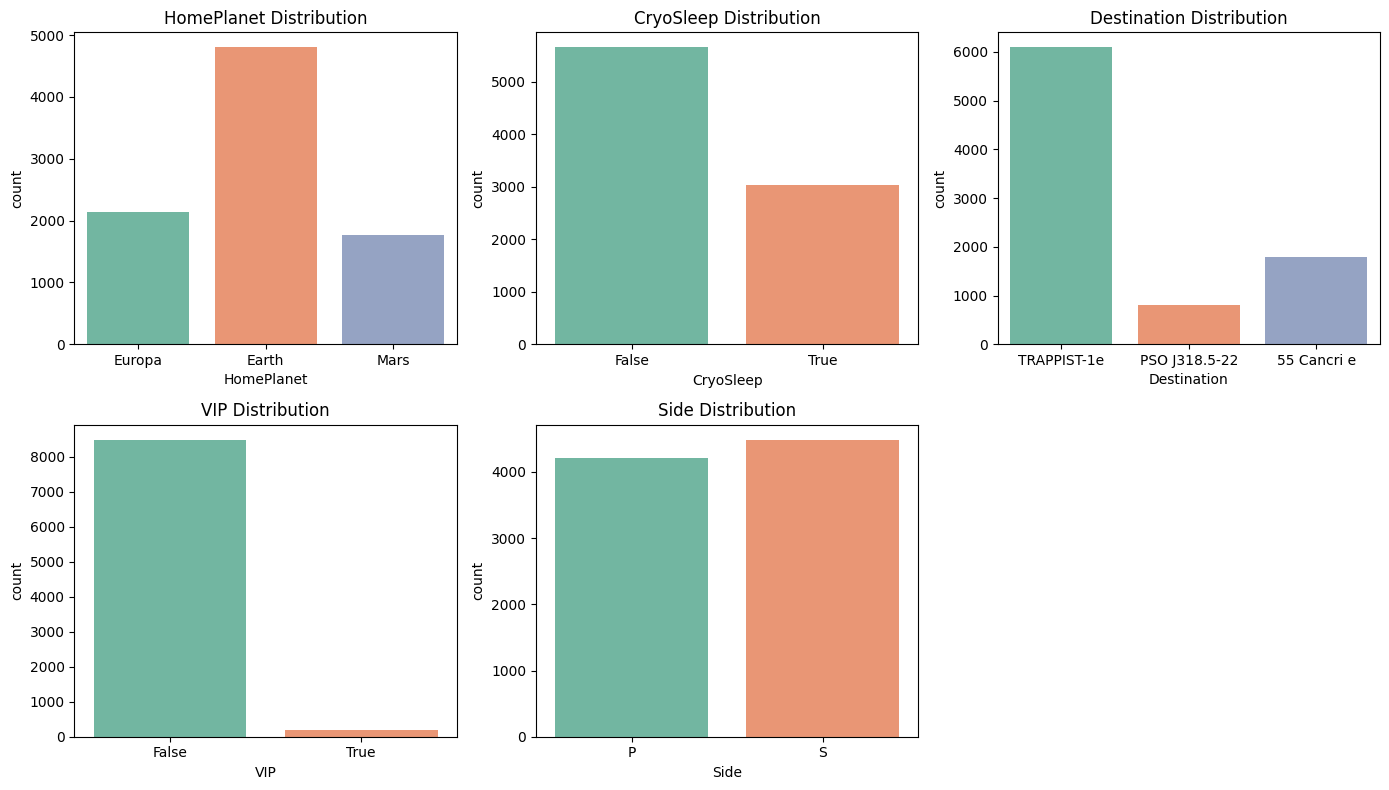

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate Categorical Features Plot (Warning Fixed)
plt.figure(figsize=(14, 8))
cat_cols = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Side']

for i, col in enumerate(cat_cols, 1):
  plt.subplot(2, 3, i)
  sns.countplot(data=df, x=col, hue=col, palette='Set2', legend=False)
  plt.title(f'{col} Distribution')

plt.tight_layout()
plt.show()

- HomePlanet: Earth se sabse zyada passengers hain (52.9%), iske baad Europa (24.5%) aur Mars (20.2%) aate hain.

- CryoSleep: Maximum passengers jaage hue the (62.6% False), jabki sirf 34.9% passengers deep sleep (True) me the.

- Destination: Sabse popular location TRAPPIST-1e hai (68.0%), jabki 55 Cancri e par 20.7% aur PSO J318.5-22 par sirf 9.2% log ja rahe the.

- VIP: Ship par normal passengers dominant hain — 95.4% non-VIP hain aur sirf 2.3% VIP passengers hain.

- Deck: Bulk passengers Deck F (32.1%) aur Deck G (29.4%) par the. Deck T (0.05%) par almost negligible log the.

- Side: Ship ke dono sides (Port vs Starboard) par almost equal population thi (48.4% Port vs 49.3% Starboard).

## Numerical Features

C:\Users\tejal\AppData\Local\Temp\ipykernel_552248\2787593210.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Deck', palette='magma')


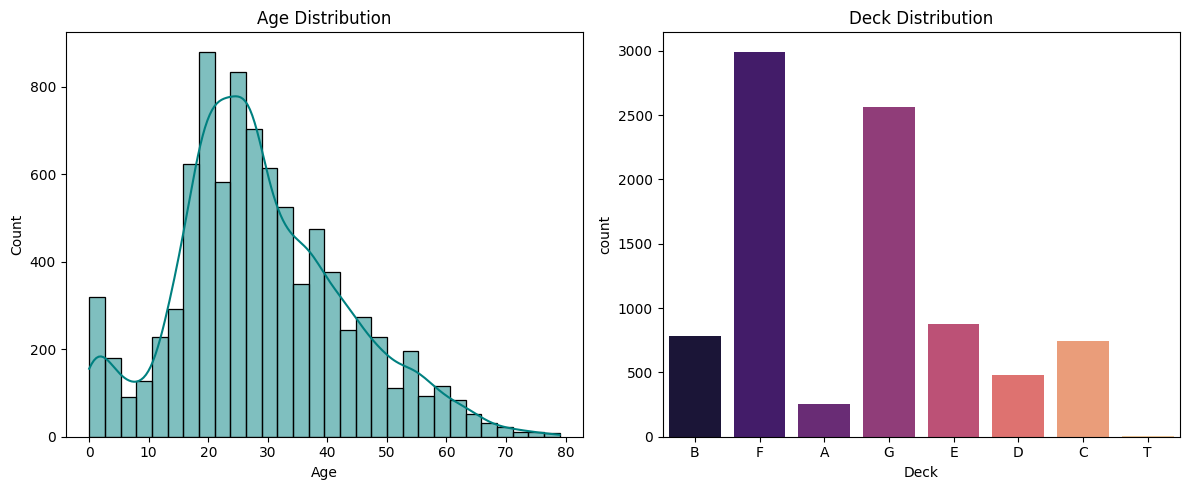

In [27]:
plt.figure(figsize=(12, 5))

# Age Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['Age'].dropna(), kde=True, color='teal', bins=30)
plt.title('Age Distribution')

# Deck Distribution
plt.subplot(1, 2, 2)
sns.countplot(data=df, x='Deck', palette='magma')
plt.title('Deck Distribution')

plt.tight_layout()
plt.show()

Age: Distribution right-skewed hai — major passenger base 18 se 35 saal ke young adults ki hai, jabki peak around ~20-25 years hai.

- Age: Distribution right-skewed hai — major passenger base 18 se 35 saal ke young adults ki hai, jabki peak around ~20-25 years hai.

## CryoSleep vs Transported Plot

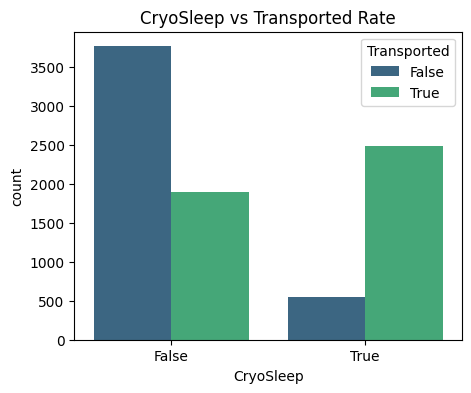

In [17]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='CryoSleep', hue='Transported', palette='viridis')
plt.title('CryoSleep vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Passengers in CryoSleep had an 81.8% transport rate, compared to just 32.9% for those who were awake.

- Passengers in deep sleep were locked in their cabins, making them heavily affected by the anomaly. This is the single strongest predictive feature.

## HomePlanet vs Transported Plot

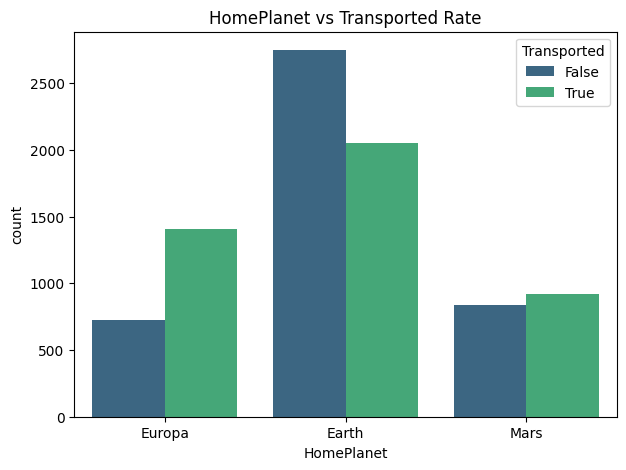

In [19]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='HomePlanet', hue='Transported', palette='viridis')
plt.title('HomePlanet vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Passengers departing from Europa had the highest transport rate (65.9%), while those from Earth had the lowest (42.4%).

- Departure origin correlates directly with cabin location and passenger tier on the ship

## Deck vs Transported Plot

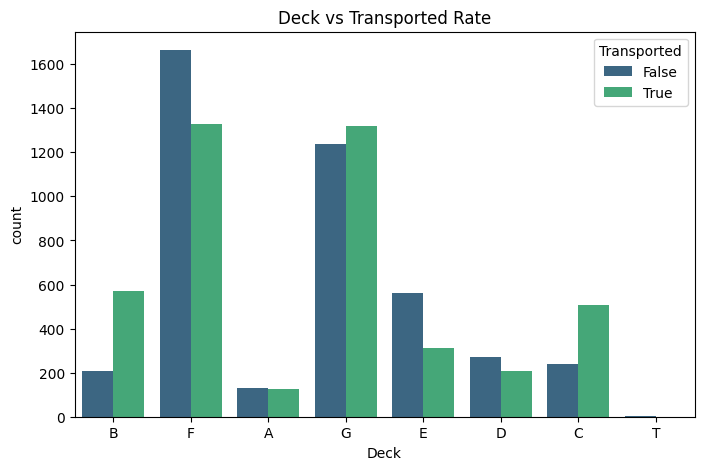

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Deck', hue='Transported', palette='viridis')
plt.title('Deck vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Deck B (73.4%) and Deck C (68.0%) recorded the highest transport rates, whereas Deck E (35.7%) and Deck F (44.0%) were safer.

- The spacetime anomaly primarily impacted the upper, luxury deck levels.

## Side (Port vs Starboard) vs Transported Plot

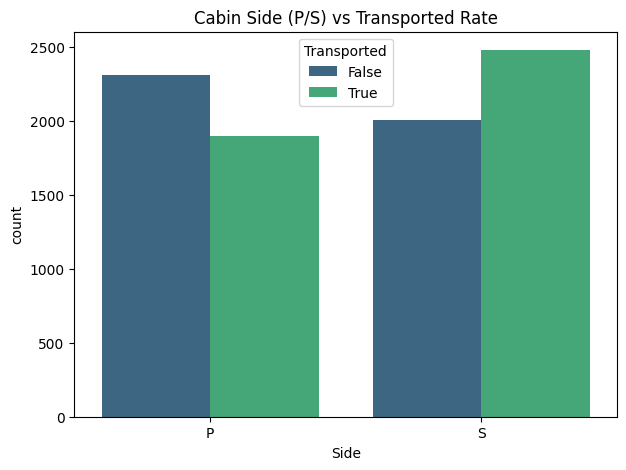

In [21]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='Side', hue='Transported', palette='viridis')
plt.title('Cabin Side (P/S) vs Transported Rate')
plt.show()

INSIGHT:
- Key Insight: Passengers on the Starboard (S) side experienced a 55.5% transport rate, which is 10% higher than the Port (P) side (45.1%).

- The physical anomaly directly struck the Starboard side of the vessel.

## Correlation Heatmap Plot

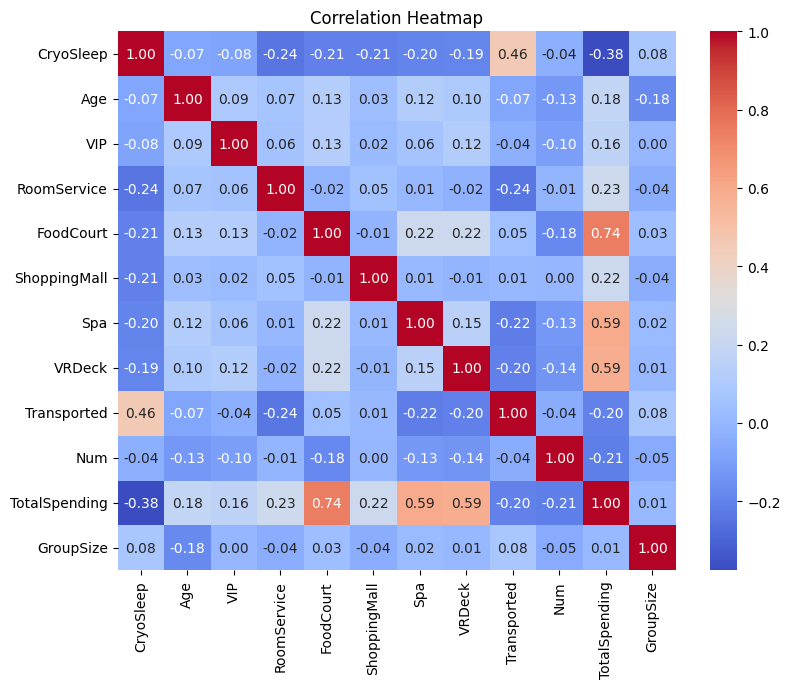

In [22]:
plt.figure(figsize=(9, 7))
numeric_df = df.select_dtypes(include=['float64', 'int64', 'bool']).copy()
numeric_df['Transported'] = numeric_df['Transported'].astype(int)

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

INSIGHT:
- Key Insight: CryoSleep shows a strong positive correlation (+0.46) with Transported, while amenity spending features show negative correlations (-0.20 to -0.24).

- Passengers moving around the ship and spending money were more likely to escape the anomaly.

## Spending Distribution Plot (Skewness Check)

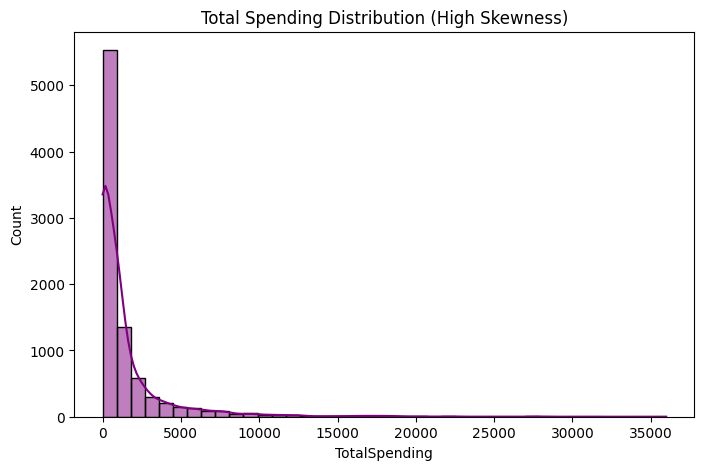

In [23]:
plt.figure(figsize=(8, 5))
sns.histplot(df['TotalSpending'], bins=40, kde=True, color='purple')
plt.title('Total Spending Distribution (High Skewness)')
plt.show()

INSIGHT:
- Key Insight: Spending data is heavily right-skewed — over 50% of passengers spent $0, while extreme outliers spent upwards of 20,000+.
- Raw spending figures will distort model learning, making log transformation (\log(x + 1)) essential in data preprocessing.

In [30]:
import numpy as np
import pandas as pd

# 1. SKEWNESS FIX (Log Transformation)
spending_cols = [
    'RoomService',
    'FoodCourt',
    'ShoppingMall',
    'Spa',
    'VRDeck',
    'TotalSpending',
]
for col in spending_cols:
  df[col] = np.log1p(df[col])  # Formula: log(1 + x)

# 2. CATEGORICAL ENCODING (Text to Numbers)

# Binary Encoding (0 aur 1 me conversion)
df['CryoSleep'] = df['CryoSleep'].astype(int)
df['VIP'] = df['VIP'].astype(int)
df['Side'] = df['Side'].map({'P': 0, 'S': 1})
df['Transported'] = df['Transported'].astype(int)

# Multi-Class One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=['HomePlanet', 'Destination', 'Deck'],
    drop_first=True,
    dtype=int,
)

# 3. DROP UNNECESSARY COLUMNS
df_final = df_encoded.drop(
    columns=['PassengerId', 'Cabin', 'Name', 'Group'], errors='ignore'
)

# Final Dataset check
print('Final Shape:', df_final.shape)
df_final.head()

Final Shape: (8693, 24)


,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Num,...,HomePlanet_Mars,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T
0,0,39.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.0,...,0,0,1,1,0,0,0,0,0,0
1,0,24.0,0,4.700480,2.302585,3.258097,6.309918,3.806662,1,0.0,...,0,0,1,0,0,0,0,1,0,0
2,0,58.0,1,3.784190,8.182280,0.000000,8.812248,3.912023,0,0.0,...,0,0,1,0,0,0,0,0,0,0
3,0,33.0,0,0.000000,7.157735,5.918894,8.110728,5.267858,0,0.0,...,0,0,1,0,0,0,0,0,0,0
4,0,16.0,0,5.717028,4.262680,5.023881,6.338594,1.098612,1,1.0,...,0,0,1,0,0,0,0,1,0,0


- np.log1p (Log Transformation): Compresses extreme spending outliers (e.g., 20,000+) into a balanced scale, preventing extreme values from skewing the model.
- map & astype(int): Converts binary categorical variables (CryoSleep, VIP, Side, and the target variable Transported) directly into numerical 0 and 1 flags.
- pd.get_dummies(..., drop_first=True): Performs One-Hot Encoding on multi-categorical columns (HomePlanet, Destination, Deck) while dropping the first category to avoid multicollinearity (the dummy variable trap).
- Column Cleanup (df_final): Removes raw text identifiers (PassengerId, Cabin, Name, Group), resulting in a fully numeric matrix ready for model training.